In [2]:
suppressPackageStartupMessages({ library(data.table); library(dplyr); library(stringr); library(ggplot2) })

In [3]:
base_dir <- "../../../data/rna/pseudobulk/results/fgsea_all_results" # paper baseline: signed -log10(p)
wald_dir <- "../../../data/rna/pseudobulk/results/fgsea_walds_results" # sensitivity: Wald statistic

read_tag <- function(path) {
  stem <- sub("^fgsea_(all|walds)_results_", "", tools::file_path_sans_ext(basename(path)))
  dt <- fread(path)
  dt[, .(contrast = stem, gmt_db, celltype, pathway, NES, padj)]
}

base_files <- list.files(base_dir, pattern = "\\.csv$", full.names = TRUE)
wald_files <- file.path(wald_dir, sub("fgsea_all_results_", "fgsea_walds_results_", basename(base_files)))

base_all <- rbindlist(lapply(base_files, read_tag))
wald_all <- rbindlist(lapply(wald_files, read_tag))

keys <- c("contrast", "gmt_db", "celltype", "pathway")
merged <- merge(
  setnames(base_all, c("NES", "padj"), c("NES_base", "padj_base")),
  setnames(wald_all, c("NES", "padj"), c("NES_wald", "padj_wald")),
  by = keys, all = FALSE
)
cat(sprintf(
  "Matched %d pathway x celltype x db x contrast rows across %d contrasts\n",
  nrow(merged), uniqueN(merged$contrast)
))

Matched 1574631 pathway x celltype x db x contrast rows across 29 contrasts


In [4]:
spear <- cor(merged$NES_base, merged$NES_wald, method = "spearman", use = "complete.obs")
pears <- cor(merged$NES_base, merged$NES_wald, method = "pearson", use = "complete.obs")
sign_agree <- mean(sign(merged$NES_base) == sign(merged$NES_wald), na.rm = TRUE)
cat(sprintf(
  "Overall NES  Spearman = %.3f | Pearson = %.3f | sign agreement = %.1f%%\n",
  spear, pears, 100 * sign_agree
))

Overall NES  Spearman = 0.972 | Pearson = 0.948 | sign agreement = 95.0%


In [5]:
sig <- merged %>% mutate(sig_base = padj_base <= 0.05, sig_wald = padj_wald <= 0.05)

n_base <- sum(sig$sig_base, na.rm = TRUE)
n_wald <- sum(sig$sig_wald, na.rm = TRUE)
n_both <- sum(sig$sig_base & sig$sig_wald, na.rm = TRUE)
jacc <- n_both / sum(sig$sig_base | sig$sig_wald, na.rm = TRUE)
retained <- n_both / n_base # % of paper-significant pathways still sig under Wald
shared <- sig %>% filter(sig_base & sig_wald)
dir_agree <- mean(sign(shared$NES_base) == sign(shared$NES_wald), na.rm = TRUE)

cat(sprintf("Significant (padj<=0.05): baseline=%d  wald=%d  both=%d\n", n_base, n_wald, n_both))
cat(sprintf(
  "Jaccard=%.3f | %% paper-significant retained under Wald=%.1f%% | direction agreement (shared sig)=%.1f%%\n",
  jacc, 100 * retained, 100 * dir_agree
))

Significant (padj<=0.05): baseline=75294  wald=104159  both=70299
Jaccard=0.644 | % paper-significant retained under Wald=93.4% | direction agreement (shared sig)=100.0%


# A tibble: 29 × 7
   contrast          n nes_spearman n_sig_base n_sig_wald pct_retained dir_agree
   <chr>         <int>        <dbl>      <int>      <int>        <dbl>     <dbl>
 1 pbmc_PI2C_vs… 54865        0.919        618       1311         84.3     100  
 2 pbmc_PI2C_vs… 57625        0.933       1412       3736         93.1     100  
 3 pbmc_PreTx_v… 58143        0.950        929       1944         93.1     100  
 4 pbmc_ASCT1y_… 54639        0.961       1559       3071         93.5     100  
 5 pbmc_ASCT2y_… 37810        0.965       1054       1798         86.6     100  
 6 bmmc_EI_vs_A… 69759        0.968       4484       6362         92.1     100.0
 7 pbmc_EI_vs_H… 52571        0.970       4165       5788         94.1     100  
 8 pbmc_PreTx_v… 63954        0.971       2524       3399         92.2     100  
 9 bmmc_PreTx_v… 63007        0.971       2806       3513         89.5     100  
10 bmmc_EI_vs_A… 58268        0.971       2528       4252         91.5     100  
11 bmmc_A

Warning message:
“Removed 15 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 15 rows containing missing values or values outside the scale range
(`geom_point()`).”


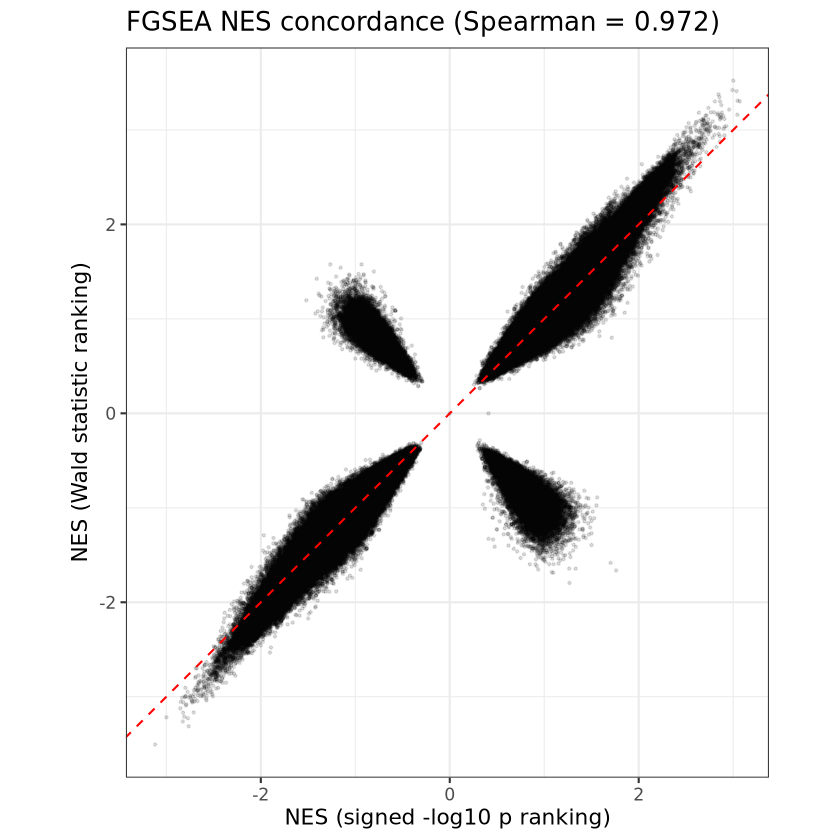

In [6]:
per_contrast <- sig %>%
  group_by(contrast) %>%
  summarise(
    n            = n(),
    nes_spearman = cor(NES_base, NES_wald, method = "spearman", use = "complete.obs"),
    n_sig_base   = sum(sig_base, na.rm = TRUE),
    n_sig_wald   = sum(sig_wald, na.rm = TRUE),
    pct_retained = 100 * sum(sig_base & sig_wald, na.rm = TRUE) / pmax(1, sum(sig_base, na.rm = TRUE)),
    dir_agree    = 100 * mean(sign(NES_base[sig_base & sig_wald]) == sign(NES_wald[sig_base & sig_wald]), na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(nes_spearman)

print(per_contrast, n = Inf)
fwrite(per_contrast, "../../../data/rna/pseudobulk/results/fgsea_metric_evaluation_per_contrast.csv")

# Cell 5 — NES scatter for the supplement
g <- ggplot(merged, aes(NES_base, NES_wald)) +
  geom_point(alpha = 0.12, size = 0.5) +
  geom_abline(slope = 1, intercept = 0, colour = "red", linetype = "dashed") +
  coord_equal() +
  labs(
    x = "NES (signed -log10 p ranking)",
    y = "NES (Wald statistic ranking)",
    title = sprintf("FGSEA NES concordance (Spearman = %.3f)", spear)
  ) +
  theme_bw(base_size = 13)

ggsave("../../../data/rna/pseudobulk/results/fgsea_metric_evaluation_NES_scatter.png", g, width = 6, height = 6, dpi = 300)
g

In [1]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
})
L3_RESULTS <- "../../../data/rna/pseudobulk/results"

compare_concordance <- function(contrast, celltypes, pathways = NULL,
                                base_dir = file.path(L3_RESULTS, "fgsea_all_results"),
                                wald_dir = file.path(L3_RESULTS, "fgsea_walds_results"),
                                padj_thresh = 0.05) {
  pick <- function(dir, prefix, tag) {
    d <- read.csv(file.path(dir, paste0(prefix, contrast, ".csv"))) %>% filter(celltype %in% celltypes)
    if (!is.null(pathways)) d <- d %>% filter(pathway %in% pathways)
    d %>%
      select(celltype, gmt_db, pathway, NES, padj) %>%
      rename(!!paste0("NES_", tag) := NES, !!paste0("padj_", tag) := padj)
  }
  full_join(pick(base_dir, "fgsea_all_results_", "base"),
    pick(wald_dir, "fgsea_walds_results_", "wald"),
    by = c("celltype", "gmt_db", "pathway")
  ) %>%
    mutate(
      contrast = contrast,
      sign_flip = sign(NES_base) != sign(NES_wald),
      sig_base = padj_base <= padj_thresh, sig_wald = padj_wald <= padj_thresh,
      sig_changed = sig_base != sig_wald,
      missing_cell = is.na(NES_base) | is.na(NES_wald)
    )
}

summarise_concordance <- function(df) {
  df %>% summarise(
    n_cells = n(),
    nes_spearman = cor(NES_base, NES_wald, method = "spearman", use = "complete.obs"),
    visible_flip = sum(sign_flip & (sig_base | sig_wald), na.rm = TRUE),
    cosmetic_flip = sum(sign_flip & !(sig_base | sig_wald), na.rm = TRUE),
    sig_lost = sum(sig_base & !sig_wald, na.rm = TRUE),
    sig_gained = sum(!sig_base & sig_wald, na.rm = TRUE),
    max_abs_nes_flip = round(suppressWarnings(max(abs(NES_base[sign_flip]), na.rm = TRUE)), 2)
  )
}

# run several (contrast, celltypes) specs for one figure
run_fig <- function(specs, pathways = NULL) {
  res <- bind_rows(lapply(specs, function(s) compare_concordance(s$contrast, s$celltypes, pathways)))
  print(summarise_concordance(res))
  res %>% filter(sign_flip & (sig_base | sig_wald)) # show only VISIBLE flips (the ones that matter)
}

In [3]:
ct <- c("CMP Core", "HSPC Multi", "Prog B Pre", "CD16 Mono Core", "CD14 Mono Core", "pDC", "cDC2 Core", "Treg", "Naive B Core", "CD8 T Naive Core", "CD4 T Naive Core", "CD4 T EM1", "CD8 T EM1", "CD56dim NK GZMK+", "CD56br NK", "Mem B Core")
pw <- c("CEBPD ENCODE", "CYTOKINE SIGNALING IN IMMUNE SYSTEM", "EPSTEIN-BARR VIRUS INFECTION", "HYPOXIA", "INTERFERON ALPHA RESPONSE", "INTERFERON GAMMA RESPONSE", "OXIDATIVE PHOSPHORYLATION", "TCR SIGNALING", "TGF-BETA SIGNALING", "TNF-ALPHA 
  SIGNALING VIA NF-KB")
run_fig(lapply(c("bmmc_PreTx_vs_Healthy", "bmmc_EI_vs_Healthy", "bmmc_ASCT1y_vs_Healthy"), function(x) list(contrast = x, celltypes = ct)), pw)

  n_cells nes_spearman visible_flip cosmetic_flip sig_lost sig_gained
1     463    0.9925873            0            16        4         23
  max_abs_nes_flip
1             0.93


celltype,gmt_db,pathway,NES_base,padj_base,NES_wald,padj_wald,contrast,sign_flip,sig_base,sig_wald,sig_changed,missing_cell
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>


In [4]:
# fig_3d
ct <- c("Treg Naive","CD16 Mono Core","CD14 Mono Core","pDC","CD8 MAIT","CD4 MAIT","Trans B","Naive B ISG+","Naive B Core","CD8 T Naive Core","CD4 T Naive SOX4+","CD4 T Naive ISG+","CD4 T Naive Core","CD4 T Mem KLRF1- GZMB+","CD4 T Mem ISG+","CD4 T EM GZMB- CD27-","CD4 T EM GZMB- CD27+","gdT Vd2 GZMK+","gdT Vd2 GZMB+","gdT Vd1 Eff KLRF1+","Prolif T","Prolif NK","CD8 T Mem ISG+","CD8 T EM KLRF1- GZMB+","CD8 T EM KLRF1+ GZMB+","CD8 T EM GZMK- CD27+","CD8 T EM GZMK+ CD27+","NK Adaptive","CD56dim NK ISG+","CD56dim NK GZMK+","CD56dim NK GZMK-","CD56br NK","Mem B Type2","Mem B Early","Mem B Core","Mem B CD95","Eff B CD27-","Eff B CD27+")
pw <- c("CEBPD ENCODE","CYTOKINE SIGNALING IN IMMUNE SYSTEM","EPSTEIN-BARR VIRUS INFECTION","HYPOXIA","INTERFERON ALPHA RESPONSE","INTERFERON GAMMA RESPONSE","OXIDATIVE PHOSPHORYLATION","TCR SIGNALING","TGF-BETA SIGNALING","TNF-ALPHA SIGNALING VIA NF-KB")
run_fig(lapply(c("pbmc_PreTx_vs_Healthy","pbmc_EI_vs_Healthy","pbmc_ASCT1y_vs_Healthy"), function(x) list(contrast=x, celltypes=ct)), pw)

  n_cells nes_spearman visible_flip cosmetic_flip sig_lost sig_gained
1    1018    0.9791036            0            27        9         71
  max_abs_nes_flip
1             1.02


celltype,gmt_db,pathway,NES_base,padj_base,NES_wald,padj_wald,contrast,sign_flip,sig_base,sig_wald,sig_changed,missing_cell
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>


In [5]:
# fig_4b
ct <- c("HSPC Stem","HSPC Multi","LMPP","CLP","CMP Core","CMP Gran","MEP","Pre Prog Ery","Prog Ery","Prog Ery Prolif","Pre Mono Core","Pre Mono Prolif","Prog B Pre","Prog B","Pre B Heavy","Pre B Light","Pre B Prolif","Prog DC cDC","Prog DC pDC")
pw <- c("IRF3 ENCODE","INTERFERON GAMMA RESPONSE","INTERFERON ALPHA RESPONSE","EPSTEIN-BARR VIRUS INFECTION","TGF-BETA SIGNALING","TNF-ALPHA SIGNALING VIA NF-KB","HYPOXIA","OXIDATIVE PHOSPHORYLATION","FOXM1 ENCODE")
run_fig(lapply(c("bmmc_PreTx_vs_Healthy","bmmc_EI_vs_Healthy","bmmc_ASCT90d_vs_Healthy","bmmc_ASCT1y_vs_Healthy","bmmc_ASCT2y_vs_Healthy"), function(x) list(contrast=x, celltypes=ct)), pw)

  n_cells nes_spearman visible_flip cosmetic_flip sig_lost sig_gained
1     776    0.9910344            0            20       16         27
  max_abs_nes_flip
1             1.29


celltype,gmt_db,pathway,NES_base,padj_base,NES_wald,padj_wald,contrast,sign_flip,sig_base,sig_wald,sig_changed,missing_cell
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>


In [6]:
# fig_4d
ct <- c("HSPC Stem","HSPC Multi","LMPP","CLP","Prog B Pre","Prog B","CMP Core","CMP Gran","MEP","Pre Prog Ery","Pre Mono Prolif","Prog DC cDC","Prog DC pDC")
pw <- c("MAPK SIGNALING PATHWAY","CYTOKINE SIGNALING IN IMMUNE SYSTEM","TNF-ALPHA SIGNALING VIA NF-KB","IL-17 SIGNALING PATHWAY")
run_fig(list(list(contrast="bmmc_EI_vs_ASCT1y", celltypes=ct)), pw)

  n_cells nes_spearman visible_flip cosmetic_flip sig_lost sig_gained
1      48    0.9587495            0             3        0          2
  max_abs_nes_flip
1             0.91


celltype,gmt_db,pathway,NES_base,padj_base,NES_wald,padj_wald,contrast,sign_flip,sig_base,sig_wald,sig_changed,missing_cell
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>


In [7]:
# fig_5e (two arms — bmmc + pbmc, same 8 pathways)
pw <- c("EPSTEIN-BARR VIRUS INFECTION","HYPOXIA","INTERFERON ALPHA RESPONSE","INTERFERON GAMMA RESPONSE","OXIDATIVE PHOSPHORYLATION","TCR SIGNALING","TGF-BETA SIGNALING","TNF-ALPHA SIGNALING VIA NF-KB")
ct_bmmc <- c("CD8 T Naive Core","CD4 T Naive Core","CD4 T EM1","CD4 T EM2","gdT","CD8 T Tissue Res","CD8 T EM2","CD8 T EM1","NK Tissue Res","NK Effector","CD56dim NK GZMK-","CD56dim NK GZMK+","CD56br NK")
ct_pbmc <- c("CD4 T Mem KLRF1- GZMB+","CD4 T Mem ISG+","CD4 T EM GZMB- CD27-","CD4 T EM GZMB- CD27+","CD4 T CM","gdT Vd2 GZMK+","gdT Vd2 GZMB+","gdT Vd1 Eff KLRF1+","Prolif T","Prolif NK","DN T","CD8 T Mem ISG+","CD8 T EM KLRF1- GZMB+","CD8 T EM KLRF1+ GZMB+","CD8 T EM GZMK- CD27+","CD8 T EM GZMK+ CD27+","CD8 T CM","NK Adaptive","CD56dim NK ISG+","CD56dim NK GZMK-","CD56dim NK GZMK+","CD56br NK")
specs <- c(lapply(c("bmmc_PreTx_vs_Healthy","bmmc_EI_vs_Healthy","bmmc_ASCT90d_vs_Healthy","bmmc_ASCT1y_vs_Healthy","bmmc_ASCT2y_vs_Healthy"), function(x) list(contrast=x, celltypes=ct_bmmc)),
           lapply(c("pbmc_PreTx_vs_Healthy","pbmc_EI_vs_Healthy","pbmc_ASCT60d_vs_Healthy","pbmc_ASCT1y_vs_Healthy","pbmc_ASCT2y_vs_Healthy"), function(x) list(contrast=x, celltypes=ct_pbmc)))
run_fig(specs, pw)

  n_cells nes_spearman visible_flip cosmetic_flip sig_lost sig_gained
1    1426    0.9883769            0            39       15         73
  max_abs_nes_flip
1             1.07


celltype,gmt_db,pathway,NES_base,padj_base,NES_wald,padj_wald,contrast,sign_flip,sig_base,sig_wald,sig_changed,missing_cell
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>


In [8]:

# fig_5i (auto-selected top-7 → test ALL pathways in its 3 cell types; conservative)
ct <- c("CD8 T EM1","CD8 T EM2","CD8 T Tissue Res")
run_fig(list(list(contrast="bmmc_EI_vs_ASCT1y", celltypes=ct)), pathways=NULL)  # NULL = all pathways


  n_cells nes_spearman visible_flip cosmetic_flip sig_lost sig_gained
1    3980    0.9636011            0           178       30         92
  max_abs_nes_flip
1             1.22


celltype,gmt_db,pathway,NES_base,padj_base,NES_wald,padj_wald,contrast,sign_flip,sig_base,sig_wald,sig_changed,missing_cell
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>


In [9]:
# fig_6f (two arms, same comp ASCT1y_vs_Healthy, same 5 pathways)
pw <- c("HYPOXIA","MAPK SIGNALING PATHWAY","INTERFERON GAMMA RESPONSE","INTERFERON ALPHA RESPONSE","TNF-ALPHA SIGNALING VIA NF-KB")
ct_pbmc <- c("Mem B Core","Naive B Core","Naive B ISG+","Trans B")
ct_bmmc <- c("CLP","Mem B Core","Naive B Core","Pre B Heavy","Pre B Prolif","Trans B Core","Pre B Light","Prog B","Prog B Pre")
run_fig(list(list(contrast="pbmc_ASCT1y_vs_Healthy", celltypes=ct_pbmc),
             list(contrast="bmmc_ASCT1y_vs_Healthy", celltypes=ct_bmmc)), pw)


  n_cells nes_spearman visible_flip cosmetic_flip sig_lost sig_gained
1      65     0.991958            0             0        2          2
  max_abs_nes_flip
1             -Inf


celltype,gmt_db,pathway,NES_base,padj_base,NES_wald,padj_wald,contrast,sign_flip,sig_base,sig_wald,sig_changed,missing_cell
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>


In [10]:
# sup_4c
ct <- c("HSPC Stem","HSPC Multi","LMPP","CLP","CMP Core","CMP Gran","MEP","Pre Prog Ery","Prog Ery","Prog Ery Prolif","Pre Mono Core","Pre Mono Prolif","Prog B Pre","Prog B","Pre B Heavy","Pre B Light","Pre B Prolif","Prog DC cDC","Prog DC pDC")
pw <- c("CELL CYCLE","DNA REPAIR","G2-M CHECKPOINT","MITOTIC SPINDLE")
run_fig(lapply(c("bmmc_PreTx_vs_Healthy","bmmc_EI_vs_Healthy","bmmc_ASCT90d_vs_Healthy","bmmc_ASCT1y_vs_Healthy","bmmc_ASCT2y_vs_Healthy"), function(x) list(contrast=x, celltypes=ct)), pw)


  n_cells nes_spearman visible_flip cosmetic_flip sig_lost sig_gained
1     429    0.9907197            0            11        2         16
  max_abs_nes_flip
1             0.93


celltype,gmt_db,pathway,NES_base,padj_base,NES_wald,padj_wald,contrast,sign_flip,sig_base,sig_wald,sig_changed,missing_cell
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>


In [11]:
# sup_4d (NES-correlation scatter; progenitors × 2 pathways across 5 contrasts)
ct <- c("Pre B Heavy","Pre B Prolif","Pre B Light","Pre Mono Prolif","Pre Mono Core","Pre Prog Ery","CMP Core","CMP Gran","CLP","LMPP","MEP","Prog DC cDC","Prog DC pDC","Prog Ery","Prog Ery Prolif","Prog B Pre","Prog B","HSPC Multi","HSPC Stem")
pw <- c("DNA REPAIR","CELL CYCLE")
run_fig(lapply(c("bmmc_PreTx_vs_Healthy","bmmc_EI_vs_Healthy","bmmc_ASCT90d_vs_Healthy","bmmc_ASCT1y_vs_Healthy","bmmc_ASCT2y_vs_Healthy"), function(x) list(contrast=x, celltypes=ct)), pw)


  n_cells nes_spearman visible_flip cosmetic_flip sig_lost sig_gained
1     273    0.9864926            0             8        1         12
  max_abs_nes_flip
1             0.93


celltype,gmt_db,pathway,NES_base,padj_base,NES_wald,padj_wald,contrast,sign_flip,sig_base,sig_wald,sig_changed,missing_cell
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>


In [12]:
# sup_4e
ct <- c("HSPC Stem","HSPC Multi","LMPP","CLP","Prog B Pre","Prog B","CMP Core","CMP Gran","MEP","Pre Prog Ery","Pre Mono Core","Pre Mono Prolif","Prog DC cDC","Prog DC pDC")
pw <- c("MAPK SIGNALING PATHWAY","TNF-ALPHA SIGNALING VIA NF-KB","CYTOKINE SIGNALING IN IMMUNE SYSTEM","IL-17 SIGNALING PATHWAY")
run_fig(list(list(contrast="bmmc_PreTx_vs_EI", celltypes=ct)), pw)


  n_cells nes_spearman visible_flip cosmetic_flip sig_lost sig_gained
1      56     0.991661            0             1        4          1
  max_abs_nes_flip
1             0.88


celltype,gmt_db,pathway,NES_base,padj_base,NES_wald,padj_wald,contrast,sign_flip,sig_base,sig_wald,sig_changed,missing_cell
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>


In [13]:
# sup_4f
ct <- c("HSPC Stem","HSPC Multi","LMPP","CLP","Prog B Pre","Prog B","CMP Core","CMP Gran","MEP","Pre Prog Ery","Pre Mono Core","Pre Mono Prolif","Prog DC cDC","Prog DC pDC")
pw <- c("CYTOKINE SIGNALING IN IMMUNE SYSTEM","TNF-ALPHA SIGNALING VIA NF-KB","IL-17 SIGNALING PATHWAY","MAPK SIGNALING PATHWAY")
run_fig(list(list(contrast="bmmc_PreTx_vs_EI", celltypes=ct)), pw)


  n_cells nes_spearman visible_flip cosmetic_flip sig_lost sig_gained
1      56     0.991661            0             1        4          1
  max_abs_nes_flip
1             0.88


celltype,gmt_db,pathway,NES_base,padj_base,NES_wald,padj_wald,contrast,sign_flip,sig_base,sig_wald,sig_changed,missing_cell
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>


In [14]:
# sup_5d
ct <- c("CD4 T EM2","CD4 T EM1","gdT","CD8 T Tissue Res","CD8 T EM2","CD8 T EM1","NK Tissue Res","NK Adaptive")
pw <- c("INFLUENZA A","EPSTEIN-BARR VIRUS INFECTION","INTERFERON GAMMA RESPONSE","INTERFERON ALPHA RESPONSE")
run_fig(list(list(contrast="bmmc_PreTx_vs_EI", celltypes=ct)), pw)


  n_cells nes_spearman visible_flip cosmetic_flip sig_lost sig_gained
1      32    0.9703079            0             1        4          2
  max_abs_nes_flip
1             1.39


celltype,gmt_db,pathway,NES_base,padj_base,NES_wald,padj_wald,contrast,sign_flip,sig_base,sig_wald,sig_changed,missing_cell
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>


In [15]:
# sup_5e
ct <- c("CD8 T EM KLRF1- GZMB+","CD8 T EM KLRF1+ GZMB+","CD8 T EM GZMK- CD27+","CD8 T EM GZMK+ CD27+","CD8 T CM","NK Adaptive","CD56dim NK ISG+")
pw <- c("INTERFERON GAMMA RESPONSE","INTERFERON ALPHA RESPONSE","INFLUENZA A","EPSTEIN-BARR VIRUS INFECTION")
run_fig(list(list(contrast="pbmc_PreTx_vs_EI", celltypes=ct)), pw)

  n_cells nes_spearman visible_flip cosmetic_flip sig_lost sig_gained
1      28    0.9359606            0             3        3          1
  max_abs_nes_flip
1             1.26


celltype,gmt_db,pathway,NES_base,padj_base,NES_wald,padj_wald,contrast,sign_flip,sig_base,sig_wald,sig_changed,missing_cell
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>


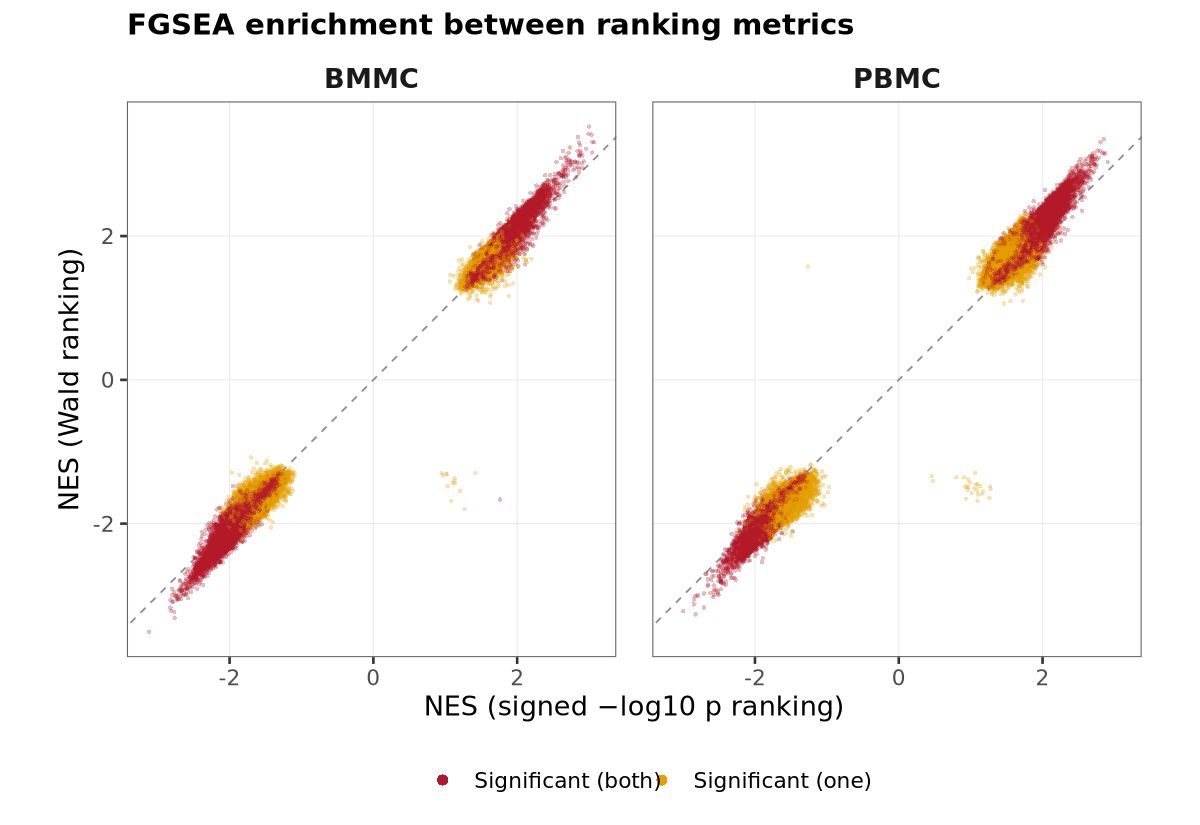

In [30]:
options(repr.plot.width = 8, repr.plot.height = 5.5, repr.plot.res = 150)

p <- ggplot(m_sig, aes(NES_base, NES_wald, color = sig)) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "grey55", linewidth = 0.4) +
  geom_point(alpha = 0.3, size = 1, stroke = 0) +
  scale_color_manual(values = c("Significant (one)"  = "#E69F00",
                                "Significant (both)" = "#B2182B")) +
  facet_wrap(~ compartment) +
  coord_equal() +
  labs(
    x = "NES (signed \u2212log10 p ranking)", y = "NES (Wald ranking)", color = NULL,
    title = "FGSEA enrichment between ranking metrics"
  ) +
  guides(color = guide_legend(override.aes = list(size = 2.5, alpha = 1))) +
  theme_bw(base_size = 13) +
  theme(
    strip.background = element_blank(),
    strip.text       = element_text(face = "bold", size = 13),
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(linewidth = 0.25, color = "grey92"),
    panel.border     = element_rect(color = "grey40", fill = NA, linewidth = 0.5),
    panel.spacing    = unit(1.2, "lines"),
    plot.title       = element_text(face = "bold", size = 14),
    plot.subtitle    = element_text(size = 10, color = "grey30", lineheight = 1.2),
    legend.position  = "bottom"
  )

ggsave(file.path(L3, "fgsea_metric_concordance_supp_sigonly.png"),
       p, width = 10, height = 5.5, dpi = 300)
p

In [1]:
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(data.table)
})

L3_RESULTS <- "../../../data/rna/pseudobulk/results"

# ---- compare one contrast (base = signed -log10 p, wald = Wald stat) ----
compare_concordance <- function(contrast, celltypes = NULL, pathways = NULL,
                                base_dir = file.path(L3_RESULTS, "fgsea_all_results"),
                                wald_dir = file.path(L3_RESULTS, "fgsea_walds_results"),
                                padj_thresh = 0.05) {
  pick <- function(dir, prefix, tag) {
    d <- read.csv(file.path(dir, paste0(prefix, contrast, ".csv")))
    if (!is.null(celltypes)) d <- d %>% filter(celltype %in% celltypes)
    if (!is.null(pathways))  d <- d %>% filter(pathway  %in% pathways)
    d %>% select(celltype, gmt_db, pathway, NES, padj) %>%
      rename(!!paste0("NES_", tag) := NES, !!paste0("padj_", tag) := padj)
  }
  full_join(pick(base_dir, "fgsea_all_results_",   "base"),
            pick(wald_dir, "fgsea_walds_results_", "wald"),
            by = c("celltype", "gmt_db", "pathway")) %>%
    mutate(
      contrast     = contrast,
      sign_flip    = sign(NES_base) != sign(NES_wald),
      sig_base     = padj_base <= padj_thresh,
      sig_wald     = padj_wald <= padj_thresh,
      missing_cell = is.na(NES_base) | is.na(NES_wald)
    )
}

# ---- per-row verdict ----
classify <- function(d) {
  d %>% mutate(status = dplyr::case_when(
    missing_cell                       ~ "missing",
    sign_flip & (sig_base | sig_wald)  ~ "VISIBLE FLIP",
    sig_base & !sig_wald               ~ "sig lost",
    !sig_base & sig_wald               ~ "sig gained",
    sign_flip & !(sig_base | sig_wald) ~ "cosmetic flip",
    sig_base & sig_wald                ~ "concordant (sig)",
    TRUE                               ~ "concordant (ns)"
  ))
}

# ---- build ONE table from a list of figures; each figure = list of blocks ----
# a block = list(contrasts = ..., celltypes = ..., pathways = ...)
build_table <- function(figs) {
  bind_rows(lapply(names(figs), function(fig) {
    blocks <- figs[[fig]]
    bind_rows(lapply(blocks, function(b) {
      bind_rows(lapply(b$contrasts, function(ct)
        compare_concordance(ct, celltypes = b$celltypes, pathways = b$pathways)))
    })) %>% mutate(figure = fig)
  })) %>%
    classify() %>%
    transmute(
      figure,
      tissue = dplyr::case_when(
        grepl("^bmmc_", contrast) ~ "BMMC",
        grepl("^pbmc_", contrast) ~ "PBMC",
        TRUE                      ~ NA_character_
      ),
      contrast, pathway, celltype, gmt_db,
      log10_fgsea = round(NES_base, 3),
      walds_fgsea = round(NES_wald, 3),
      delta_nes   = round(NES_wald - NES_base, 3),
      padj_log10  = signif(padj_base, 3),
      padj_wald   = signif(padj_wald, 3),
      status
    ) %>%
    arrange(figure, contrast, pathway, celltype)
}

# ============================ ALL FIGURE SPECS ============================
figs <- list(

  # ---- Figure 3 ----
  fig_3c = list(list(
    contrasts = c("bmmc_PreTx_vs_Healthy","bmmc_EI_vs_Healthy","bmmc_ASCT1y_vs_Healthy"),
    celltypes = c("CMP Core","HSPC Multi","Prog B Pre","CD16 Mono Core","CD14 Mono Core","pDC","cDC2 Core","Treg","Naive B Core","CD8 T Naive Core","CD4 T Naive Core","CD4 T EM1","CD8 T EM1","CD56dim NK GZMK+","CD56br NK","Mem B Core"),
    pathways  = c("CEBPD ENCODE","CYTOKINE SIGNALING IN IMMUNE SYSTEM","EPSTEIN-BARR VIRUS INFECTION","HYPOXIA","INTERFERON ALPHA RESPONSE","INTERFERON GAMMA RESPONSE","OXIDATIVE PHOSPHORYLATION","TCR SIGNALING","TGF-BETA SIGNALING","TNF-ALPHA SIGNALING VIA NF-KB"))),

  fig_3d = list(list(
    contrasts = c("pbmc_PreTx_vs_Healthy","pbmc_EI_vs_Healthy","pbmc_ASCT1y_vs_Healthy"),
    celltypes = c("Treg Naive","CD16 Mono Core","CD14 Mono Core","pDC","CD8 MAIT","CD4 MAIT","Trans B","Naive B ISG+","Naive B Core","CD8 T Naive Core","CD4 T Naive SOX4+","CD4 T Naive ISG+","CD4 T Naive Core","CD4 T Mem KLRF1- GZMB+","CD4 T Mem ISG+","CD4 T EM GZMB- CD27-","CD4 T EM GZMB- CD27+","gdT Vd2 GZMK+","gdT Vd2 GZMB+","gdT Vd1 Eff KLRF1+","Prolif T","Prolif NK","CD8 T Mem ISG+","CD8 T EM KLRF1- GZMB+","CD8 T EM KLRF1+ GZMB+","CD8 T EM GZMK- CD27+","CD8 T EM GZMK+ CD27+","NK Adaptive","CD56dim NK ISG+","CD56dim NK GZMK+","CD56dim NK GZMK-","CD56br NK","Mem B Type2","Mem B Early","Mem B Core","Mem B CD95","Eff B CD27-","Eff B CD27+"),
    pathways  = c("CEBPD ENCODE","CYTOKINE SIGNALING IN IMMUNE SYSTEM","EPSTEIN-BARR VIRUS INFECTION","HYPOXIA","INTERFERON ALPHA RESPONSE","INTERFERON GAMMA RESPONSE","OXIDATIVE PHOSPHORYLATION","TCR SIGNALING","TGF-BETA SIGNALING","TNF-ALPHA SIGNALING VIA NF-KB"))),

  # ---- Figure 4 ----
  fig_4b = list(list(
    contrasts = c("bmmc_PreTx_vs_Healthy","bmmc_EI_vs_Healthy","bmmc_ASCT90d_vs_Healthy","bmmc_ASCT1y_vs_Healthy","bmmc_ASCT2y_vs_Healthy"),
    celltypes = c("HSPC Stem","HSPC Multi","LMPP","CLP","CMP Core","CMP Gran","MEP","Pre Prog Ery","Prog Ery","Prog Ery Prolif","Pre Mono Core","Pre Mono Prolif","Prog B Pre","Prog B","Pre B Heavy","Pre B Light","Pre B Prolif","Prog DC cDC","Prog DC pDC"),
    pathways  = c("IRF3 ENCODE","INTERFERON GAMMA RESPONSE","INTERFERON ALPHA RESPONSE","EPSTEIN-BARR VIRUS INFECTION","TGF-BETA SIGNALING","TNF-ALPHA SIGNALING VIA NF-KB","HYPOXIA","OXIDATIVE PHOSPHORYLATION","FOXM1 ENCODE"))),

  fig_4d = list(list(
    contrasts = c("bmmc_EI_vs_ASCT1y"),
    celltypes = c("HSPC Stem","HSPC Multi","LMPP","CLP","Prog B Pre","Prog B","CMP Core","CMP Gran","MEP","Pre Prog Ery","Pre Mono Prolif","Prog DC cDC","Prog DC pDC"),
    pathways  = c("MAPK SIGNALING PATHWAY","CYTOKINE SIGNALING IN IMMUNE SYSTEM","TNF-ALPHA SIGNALING VIA NF-KB","IL-17 SIGNALING PATHWAY"))),

  # ---- Figure 5 ----
  # two arms: bmmc + pbmc, same pathways
  fig_5e = list(
    list(contrasts = c("bmmc_PreTx_vs_Healthy","bmmc_EI_vs_Healthy","bmmc_ASCT90d_vs_Healthy","bmmc_ASCT1y_vs_Healthy","bmmc_ASCT2y_vs_Healthy"),
         celltypes = c("CD8 T Naive Core","CD4 T Naive Core","CD4 T EM1","CD4 T EM2","gdT","CD8 T Tissue Res","CD8 T EM2","CD8 T EM1","NK Tissue Res","NK Effector","CD56dim NK GZMK-","CD56dim NK GZMK+","CD56br NK"),
         pathways  = c("EPSTEIN-BARR VIRUS INFECTION","HYPOXIA","INTERFERON ALPHA RESPONSE","INTERFERON GAMMA RESPONSE","OXIDATIVE PHOSPHORYLATION","TCR SIGNALING","TGF-BETA SIGNALING","TNF-ALPHA SIGNALING VIA NF-KB")),
    list(contrasts = c("pbmc_PreTx_vs_Healthy","pbmc_EI_vs_Healthy","pbmc_ASCT60d_vs_Healthy","pbmc_ASCT1y_vs_Healthy","pbmc_ASCT2y_vs_Healthy"),
         celltypes = c("CD4 T Mem KLRF1- GZMB+","CD4 T Mem ISG+","CD4 T EM GZMB- CD27-","CD4 T EM GZMB- CD27+","CD4 T CM","gdT Vd2 GZMK+","gdT Vd2 GZMB+","gdT Vd1 Eff KLRF1+","Prolif T","Prolif NK","DN T","CD8 T Mem ISG+","CD8 T EM KLRF1- GZMB+","CD8 T EM KLRF1+ GZMB+","CD8 T EM GZMK- CD27+","CD8 T EM GZMK+ CD27+","CD8 T CM","NK Adaptive","CD56dim NK ISG+","CD56dim NK GZMK-","CD56dim NK GZMK+","CD56br NK"),
         pathways  = c("EPSTEIN-BARR VIRUS INFECTION","HYPOXIA","INTERFERON ALPHA RESPONSE","INTERFERON GAMMA RESPONSE","OXIDATIVE PHOSPHORYLATION","TCR SIGNALING","TGF-BETA SIGNALING","TNF-ALPHA SIGNALING VIA NF-KB"))),

  # 7 explicit pathways (was NULL) -- 5 are unique to this panel
  fig_5i = list(list(
    contrasts = c("bmmc_EI_vs_ASCT1y"),
    celltypes = c("CD8 T EM1","CD8 T EM2","CD8 T Tissue Res"),
    pathways  = c("NELFE ENCODE","TNF-ALPHA SIGNALING VIA NF-KB","STAT3 ENCODE","SMC3 ENCODE","NFE2L2 CHEA","INTERFERON SIGNALING","CYTOKINE SIGNALING IN IMMUNE SYSTEM"))),

  # ---- Figure 6 ----
  # arm1 = pbmc panel actually in fig_6f.ipynb (added cDC1/pDC; pathways corrected to EBV/TNF/IFN-a/IFN-g)
  # arm2 = bmmc B-lineage arm from your original list -- NO notebook currently generates this; data exists if you build it. Confirm/remove.
  fig_6f = list(
    list(contrasts = c("pbmc_ASCT1y_vs_Healthy"),
         celltypes = c("Mem B Core","Naive B Core","Naive B ISG+","Trans B","cDC1","pDC"),
         pathways  = c("EPSTEIN-BARR VIRUS INFECTION","TNF-ALPHA SIGNALING VIA NF-KB","INTERFERON ALPHA RESPONSE","INTERFERON GAMMA RESPONSE")),
    list(contrasts = c("bmmc_ASCT1y_vs_Healthy"),
         celltypes = c("CLP","Mem B Core","Naive B Core","Pre B Heavy","Pre B Prolif","Trans B Core","Pre B Light","Prog B","Prog B Pre"),
         pathways  = c("HYPOXIA","MAPK SIGNALING PATHWAY","INTERFERON GAMMA RESPONSE","INTERFERON ALPHA RESPONSE","TNF-ALPHA SIGNALING VIA NF-KB"))),

  # ---- Supplementary 4 ----
  sup_4c = list(list(
    contrasts = c("bmmc_PreTx_vs_Healthy","bmmc_EI_vs_Healthy","bmmc_ASCT90d_vs_Healthy","bmmc_ASCT1y_vs_Healthy","bmmc_ASCT2y_vs_Healthy"),
    celltypes = c("HSPC Stem","HSPC Multi","LMPP","CLP","CMP Core","CMP Gran","MEP","Pre Prog Ery","Prog Ery","Prog Ery Prolif","Pre Mono Core","Pre Mono Prolif","Prog B Pre","Prog B","Pre B Heavy","Pre B Light","Pre B Prolif","Prog DC cDC","Prog DC pDC"),
    pathways  = c("CELL CYCLE","DNA REPAIR","G2-M CHECKPOINT","MITOTIC SPINDLE"))),

  sup_4d = list(list(
    contrasts = c("bmmc_PreTx_vs_Healthy","bmmc_EI_vs_Healthy","bmmc_ASCT90d_vs_Healthy","bmmc_ASCT1y_vs_Healthy","bmmc_ASCT2y_vs_Healthy"),
    celltypes = c("Pre B Heavy","Pre B Prolif","Pre B Light","Pre Mono Prolif","Pre Mono Core","Pre Prog Ery","CMP Core","CMP Gran","CLP","LMPP","MEP","Prog DC cDC","Prog DC pDC","Prog Ery","Prog Ery Prolif","Prog B Pre","Prog B","HSPC Multi","HSPC Stem"),
    pathways  = c("DNA REPAIR","CELL CYCLE"))),

  # CORRECTED: real sup_4e uses PreTx_vs_Healthy
  sup_4e = list(list(
    contrasts = c("bmmc_PreTx_vs_Healthy"),
    celltypes = c("HSPC Stem","HSPC Multi","LMPP","CLP","Prog B Pre","Prog B","CMP Core","CMP Gran","MEP","Pre Prog Ery","Pre Mono Core","Pre Mono Prolif","Prog DC cDC","Prog DC pDC"),
    pathways  = c("MAPK SIGNALING PATHWAY","TNF-ALPHA SIGNALING VIA NF-KB","CYTOKINE SIGNALING IN IMMUNE SYSTEM","IL-17 SIGNALING PATHWAY"))),

  # NEW: sup_4f uses PreTx_vs_EI (this is what your old sup_4e entry actually was)
  sup_4f = list(list(
    contrasts = c("bmmc_PreTx_vs_EI"),
    celltypes = c("HSPC Stem","HSPC Multi","LMPP","CLP","Prog B Pre","Prog B","CMP Core","CMP Gran","MEP","Pre Prog Ery","Pre Mono Core","Pre Mono Prolif","Prog DC cDC","Prog DC pDC"),
    pathways  = c("IL-17 SIGNALING PATHWAY","TNF-ALPHA SIGNALING VIA NF-KB","CYTOKINE SIGNALING IN IMMUNE SYSTEM","MAPK SIGNALING PATHWAY"))),

  # ---- Supplementary 5 ----
  sup_5d = list(list(
    contrasts = c("bmmc_PreTx_vs_EI"),
    celltypes = c("CD4 T EM2","CD4 T EM1","gdT","CD8 T Tissue Res","CD8 T EM2","CD8 T EM1","NK Tissue Res","NK Adaptive"),
    pathways  = c("INFLUENZA A","EPSTEIN-BARR VIRUS INFECTION","INTERFERON GAMMA RESPONSE","INTERFERON ALPHA RESPONSE"))),

  sup_5e = list(list(
    contrasts = c("pbmc_PreTx_vs_EI"),
    celltypes = c("CD8 T EM KLRF1- GZMB+","CD8 T EM KLRF1+ GZMB+","CD8 T EM GZMK- CD27+","CD8 T EM GZMK+ CD27+","CD8 T CM","NK Adaptive","CD56dim NK ISG+"),
    pathways  = c("INTERFERON GAMMA RESPONSE","INTERFERON ALPHA RESPONSE","INFLUENZA A","EPSTEIN-BARR VIRUS INFECTION")))
)

# ============================ RUN ============================
tbl <- build_table(figs)

# quick verdict per figure
verdict <- tbl %>%
  group_by(figure) %>%
  summarise(
    n_rows       = n(),
    visible_flip = sum(status == "VISIBLE FLIP"),
    sig_lost     = sum(status == "sig lost"),
    sig_gained   = sum(status == "sig gained"),
    all_clear    = visible_flip == 0,
    .groups = "drop"
  )

print(verdict, n = Inf)
fwrite(tbl,     file.path(L3_RESULTS, "fgsea_metric_evaluation_detailed.csv"))
fwrite(verdict, file.path(L3_RESULTS, "fgsea_metric_evaluation_verdict.csv"))

# A tibble: 13 × 6
   figure n_rows visible_flip sig_lost sig_gained all_clear
   <chr>   <int>        <int>    <int>      <int> <lgl>    
 1 fig_3c    510            0        4         23 TRUE     
 2 fig_3d   1018            0        9         71 TRUE     
 3 fig_4b    776            0       16         27 TRUE     
 4 fig_4d     48            0        0          2 TRUE     
 5 fig_5e   1426            0       15         73 TRUE     
 6 fig_5i     21            0        0          0 TRUE     
 7 fig_6f     69            0        2          0 TRUE     
 8 sup_4c    429            0        2         16 TRUE     
 9 sup_4d    273            0        1         12 TRUE     
10 sup_4e     56            0        4          1 TRUE     
11 sup_4f     56            0        4          1 TRUE     
12 sup_5d     32            0        4          2 TRUE     
13 sup_5e     28            0        3          1 TRUE     


In [2]:
head(tbl)

,figure,tissue,contrast,pathway,celltype,gmt_db,log10_fgsea,walds_fgsea,delta_nes,padj_log10,padj_wald,status
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,fig_3c,BMMC,bmmc_ASCT1y_vs_Healthy,CEBPD ENCODE,CD14 Mono Core,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X.gmt,-1.333,-1.303,0.030,5.26e-02,1.21e-01,concordant (ns)
2,fig_3c,BMMC,bmmc_ASCT1y_vs_Healthy,CEBPD ENCODE,CD16 Mono Core,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X.gmt,-1.689,-1.704,-0.015,4.68e-06,3.01e-06,concordant (sig)
3,fig_3c,BMMC,bmmc_ASCT1y_vs_Healthy,CEBPD ENCODE,CD4 T EM1,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X.gmt,-1.285,-1.328,-0.042,1.13e-01,9.55e-02,concordant (ns)
4,fig_3c,BMMC,bmmc_ASCT1y_vs_Healthy,CEBPD ENCODE,CD4 T Naive Core,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X.gmt,-1.622,-1.666,-0.044,6.46e-04,1.47e-04,concordant (sig)
5,fig_3c,BMMC,bmmc_ASCT1y_vs_Healthy,CEBPD ENCODE,CD56br NK,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X.gmt,-1.158,-1.229,-0.071,4.45e-01,2.50e-01,concordant (ns)
6,fig_3c,BMMC,bmmc_ASCT1y_vs_Healthy,CEBPD ENCODE,CD56dim NK GZMK+,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X.gmt,-1.428,-1.423,0.006,1.46e-02,2.47e-02,concordant (sig)


In [3]:
verdict

figure,n_rows,visible_flip,sig_lost,sig_gained,all_clear
<chr>,<int>,<int>,<int>,<int>,<lgl>
fig_3c,510,0,4,23,TRUE
fig_3d,1018,0,9,71,TRUE
fig_4b,776,0,16,27,TRUE
fig_4d,48,0,0,2,TRUE
fig_5e,1426,0,15,73,TRUE
fig_5i,21,0,0,0,TRUE
fig_6f,69,0,2,0,TRUE
sup_4c,429,0,2,16,TRUE
sup_4d,273,0,1,12,TRUE


In [4]:
# split the final table by tissue and save each
tbl_bmmc <- tbl %>% filter(tissue == "BMMC")
tbl_pbmc <- tbl %>% filter(tissue == "PBMC")

fwrite(tbl_bmmc, file.path(L3_RESULTS, "bmmc_fgsea_metric_evaluation.csv"))
fwrite(tbl_pbmc, file.path(L3_RESULTS, "pbmc_fgsea_metric_evaluation.csv"))

cat(sprintf("BMMC: %d rows | PBMC: %d rows\n", nrow(tbl_bmmc), nrow(tbl_pbmc)))

BMMC: 2811 rows | PBMC: 1931 rows
